In [1]:
# 복잔한 비즈니스 로직, 조건 분기, 사용자 상호 작용, Tool호출, 결과 기반 분석, 흐름 자동화 구현
# Agent + Workflow + Business Logic + user interaction
# LLM으로 페르소나를 뽑아 그 사람에게 맞는 쇼핑 검색어를 자동 생성, 수정하는 LangGraph 구현
# 강남에서 활동하는 20대 여성이 좋아하는 향수를 소개해줘 ...
!pip install -U langgraph langchain langchain-community langchain-openai python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.1/157.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 476.0/476.0 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langgraph-sdk
    Found existing installation: langgraph-sdk 0.2.15
    Uninstalling langgraph-sdk-0.2.15:

In [2]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

import json
import re
import os
from dotenv import load_dotenv
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise RuntimeError("OPENAI_API_KEY is not set")
llm = ChatOpenAI(model_name="gpt-4o-mini", openai_api_key=OPENAI_API_KEY, temperature=0.3)

In [3]:
# LLM
def extract_list_from_llm_output(text:str):
  # 1. 코드 블럭 제거 (```...``` 사이에 있는 부분에서 백틱만 제거)
  text = re.sub(r"```[\s\S]*?```", lambda m:m.group(0).strip("`"), text)

  # 코드 블럭 시작에 자주 붙는 ```json 제거
  text = text.replace("```json", "").replace("```", "").strip()

  # 2. JSON으로 파싱
  try:
    return json.loads(text)
  except:
    pass

  # 3. 파이썬 리스트 문법으로 eval 사용
  try:
    return eval(text)     # ["a", "b"] 같은 문자열을 실제 리스트로 변환
  except:
    pass

  return [text]

In [6]:
from prompt_toolkit.shortcuts.progress_bar import Rainbow
from typing_extensions import ParamSpecArgs
# State 정의
class WorkflowState(TypedDict, total=False):
  raw_input:str        # 사용자가 처음 입력한 설명 문자
  persona_info:str     # LLM이 추출한 사람 정보
  query_candidates:List[str]    # 검색어 후보 목록
  final_queries:List[str]      # 검증이 끝난 최종 검색어 목록
  needs_fix:bool               # 후보 검색어 수정 여부
  reasoning:str                # 왜 수정이 필요한지에 대한 LLM 설명

# 페르소나 추출 노드
def extract_persona(state:WorkflowState) -> WorkflowState:
  # 입력한 문장에서 나이/성별/취향 등의 특징을 추출
  prompt = f"""
    아래 문장에서 사람의 특징을 구조적으로 추출해줘.
    출력은 JSON(dict)형식으로 부탁해.

    입력 문장 :
    {state["raw_input"]}
  """
  persona = llm.invoke(prompt).content

  # JSON 문자열로 얻은 자료를 dict로 파싱
  try:
    persona_dict = json.loads(persona)
  except json.JSONDecodeError:
    persona_dict = {"raw":persona}

  return {"persona_info":persona_dict}


# 검색 쿼리 생성 노드
def generate_query_node(state:WorkflowState) -> WorkflowState:
  # 추출된 persona_info를 근거로 쇼핑몰 검색에 사용할 후보를 생성
  prompt = f"""
    아래 사용자의 persona를 기반으로 쇼핑몰 검색 키워드 후보 5개를 만들어줘.

    persona:
    {state["persona_info"]}

    출력은 파이썬 리스트 형태로 출력하고 절대로 ```json 또는 코드 블럭을 사용하지마.
  """

  raw = llm.invoke(prompt).content
  parsed = extract_list_from_llm_output(raw)
  return {"query_candidates":parsed}


# 후보 쿼리 검증 노드
def validate_queries(state:WorkflowState) -> WorkflowState:
  # query_candidates가 persona_info와 잘 맞는지 LLM에게 검증 요청
  prompt = f"""
    아래 검색 쿼리가 persona와 잘 맞는지(적합한지) 검사해줘.
    출력은 JSON(dict)로만 출력하고 절대로 ```json 또는 코드 블럭을 사용하지마.

    persona:
    {state['persona_info']}

    candidates:
    {state['query_candidates']}

    형식:
    {{
      "needs_fix":true/false,
      "reasoning":"검증에 필요한 이유, 왜 그런 판단을 했는지 한글로 정확하게 설명해줘"
    }}
  """
  raw = llm.invoke(prompt).content

  try:
    res_dict = json.loads(raw)    # JSON 파싱 시도
  except:
    try:
      res_dict = eval(raw)        # JSON이 아니면 eval로 dict 변환 시도
    except:
      res_dict = {"needs_fix":False, "reasoning":"[경고] 파싱 실패"}

  return {
      "needs_fix":res_dict.get("needs_fix", False),
      "reasoning":res_dict.get("reasoning")
  }


# 검색 쿼리 수정 노드
def fix_queries(state:WorkflowState) -> WorkflowState:
  prompt = f"""
    persona:
    {state["persona_info"]}

    기존 candidates 쿼리:
    {state['query_candidates']}

    persona에 더 잘 맞도록 새로운 검색 쿼리 5개를 리스트 형태로만 출력해줘.
  """
  raw = llm.invoke(prompt).content
  parsed = extract_list_from_llm_output(raw)
  return {"final_queries":parsed}


# 검색 쿼리 확정 노드 : needs_fix가 False일 때 호출
def final_accept(state:WorkflowState) -> WorkflowState:
  return {"final_queries":state["query_candidates"]}

최종 검색 결과 : ['겨울철 남성 테크 제품', '멋진 겨울 아우터', '20대 남성용 스마트 기기', '겨울철 패션 아이템', '테크 스타일 남성 의류']


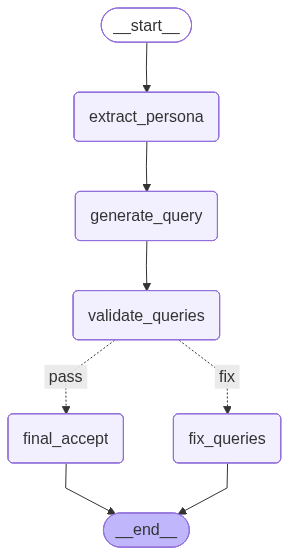

In [7]:
# LangGraph 구성
def build_graph():
  graph = StateGraph(WorkflowState)

  graph.add_node("extract_persona", extract_persona)
  graph.add_node("generate_query", generate_query_node)
  graph.add_node("validate_queries", validate_queries)
  graph.add_node("fix_queries", fix_queries)
  graph.add_node("final_accept", final_accept)

  graph.set_entry_point("extract_persona")

  graph.add_edge("extract_persona", "generate_query")     # 페르소나 -> 검색어 생성
  graph.add_edge("generate_query", "validate_queries")    # 검색어 생성 -> 검증

  # 조건 분기
  def check_fix(state:WorkflowState):    # 내부 함수 ; 함수 내 함수
    # needs_fix 값이 True면 "fix" 아니면 "pass"
    return "fix" if state["needs_fix"] else "pass"

  graph.add_conditional_edges(       # validate_queries 노드 다음에 조건 분기 설정
      "validate_queries",       # 분기가 일어나는 기준 노드
      check_fix,
      {
          "fix": "fix_queries",
          "pass": "final_accept"
      }
  )

  graph.add_edge("fix_queries", END)
  graph.add_edge("final_accept", END)
  return graph.compile()

if __name__ == "__main__":
  app = build_graph()

  user_input = "20대 남성이고, 테크 제품 좋아하고, 겨울철에는 멋지게 옷 입는 것을 좋아해"
  final_state = app.invoke({"raw_input":user_input})
  print(f"최종 검색 결과 : {final_state["final_queries"]}")

  from IPython.display import Image, display
  g = app.get_graph()
  png_bytes = g.draw_mermaid_png()
  display(Image(data=png_bytes))